# 09 - Intermediate Fusion 4-Class (Analisis Tambahan)

**Tujuan:** Melatih model Intermediate Fusion yang menggabungkan fitur penampilan (CNN) dan fitur geometrik (FCNN) di level fitur (feature-level) untuk klasifikasi 4 kelas emosi.

**Arsitektur:**
- Image stream (CNN): 3 Conv blocks -> 256-dim feature vector
- Landmark stream (FCNN): 4 Dense layers -> 128-dim feature vector
- Concatenate (384-dim) -> Dense(512->256) -> 4 classes

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusion
from training.utils import (
    EmotionMultimodalDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "4class" / "intermediate_fusion"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 16
EPOCHS = 80
LR = 0.0001
PATIENCE = 25
NUM_CLASSES = 4

EMOTIONS = ["neutral", "happy", "sad", "negative"]
print(f"Dataset: {DATASET_DIR}")
print(f"Dataset augmented: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class
Dataset augmented: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/intermediate_fusion


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=16):
    """Load train/val/test dataloaders for multimodal (images + landmarks)."""
    train_ds = EmotionMultimodalDataset(
        dataset_dir / "X_train_images.npy",
        dataset_dir / "X_train_landmarks.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionMultimodalDataset(
        dataset_dir / "X_val_images.npy",
        dataset_dir / "X_val_landmarks.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionMultimodalDataset(
        dataset_dir / "X_test_images.npy",
        dataset_dir / "X_test_landmarks.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
    negative: 145


## 3. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = IntermediateFusion(num_classes=NUM_CLASSES, landmark_dim=136).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_4c_b1_baseline.pth")
)

Model parameters: 52,465,700
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8423     0.7298     0.7113    0.9284   0.2407   0.000100  (47.3s)


     2      0.6704     0.8024     0.6499    0.9267   0.2405   0.000100  (46.9s)


     3      0.6294     0.8015     0.5542    0.9250   0.2403   0.000100  (46.8s)


     4      0.6016     0.8076     0.4703    0.9276   0.2406   0.000100  (46.6s)


...

    32      0.1868     0.9285     0.5446    0.8177   0.3046   0.000025  (46.3s)


    33      0.1969     0.9274     0.6309    0.7743   0.2923   0.000025  (46.3s)


    34      0.1760     0.9345     0.5713    0.8092   0.3106   0.000025  (46.3s)


    35      0.1731     0.9373     0.5747    0.8169   0.3120   0.000025  (46.2s)


    36      0.1694     0.9380     0.6190    0.7956   0.3146   0.000025  (46.3s)

Early stopping at epoch 36. Best epoch: 11 (val_f1=0.4005)

Best: epoch 11, val_acc=0.9353, val_f1=0.4005
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/intermediate_fusion/intermediate_4c_b1_baseline.pth


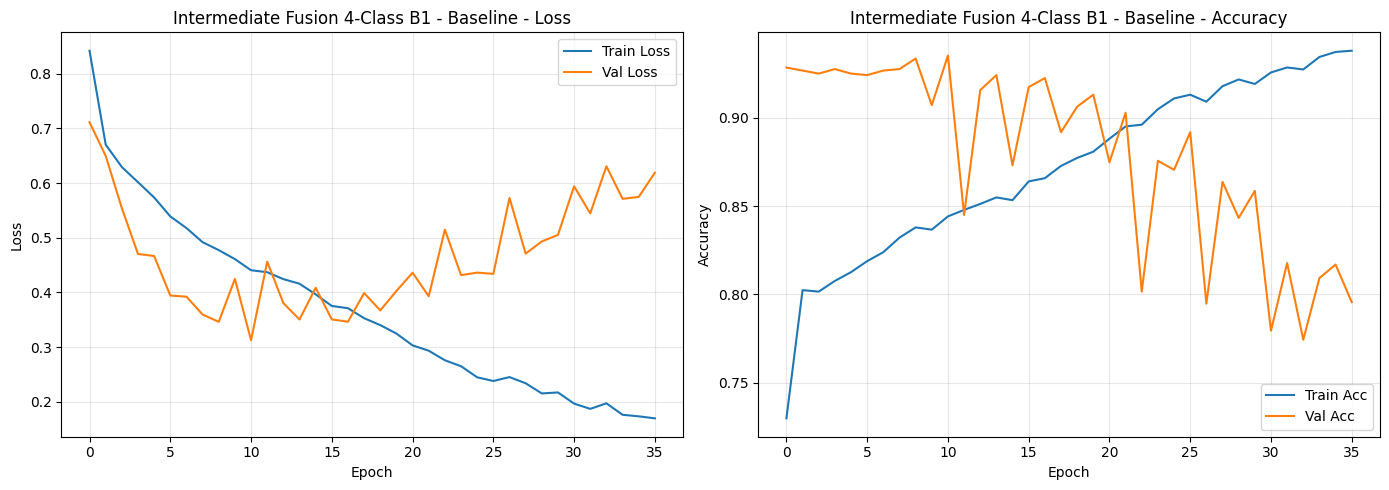

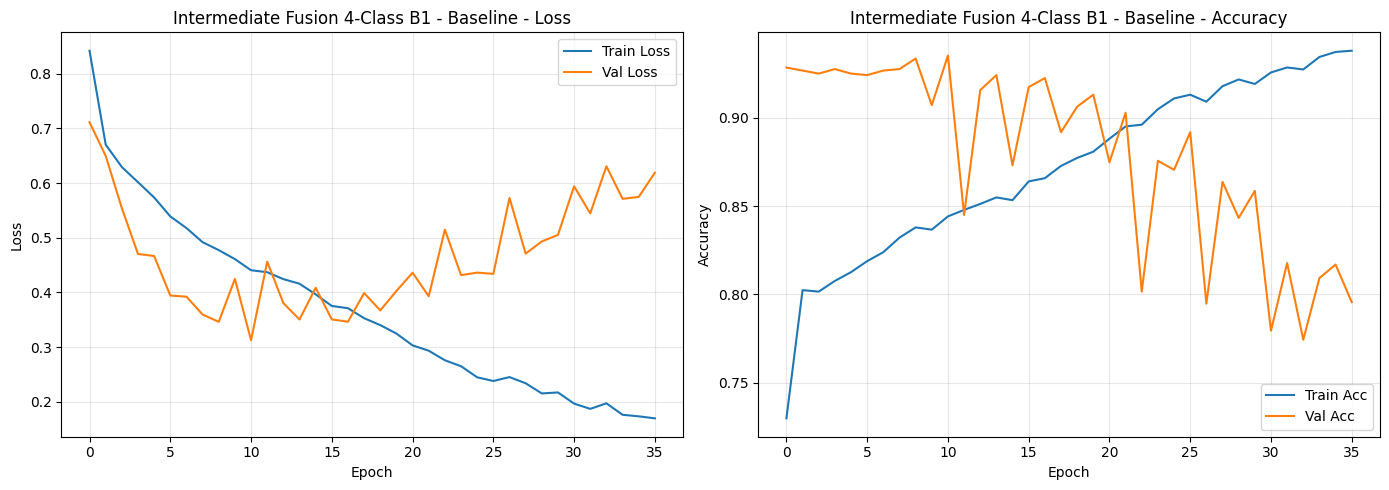

In [5]:
plot_training_history(history_b1, "Intermediate Fusion 4-Class B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.3744
Test Accuracy: 0.9191
Test Macro F1: 0.2451
Test Weighted F1: 0.9190

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.96      0.96      1588
       happy       0.00      0.00      0.00        10
         sad       0.02      0.03      0.02        38
    negative       0.00      0.00      0.00        20

    accuracy                           0.92      1656
   macro avg       0.24      0.25      0.25      1656
weighted avg       0.92      0.92      0.92      1656



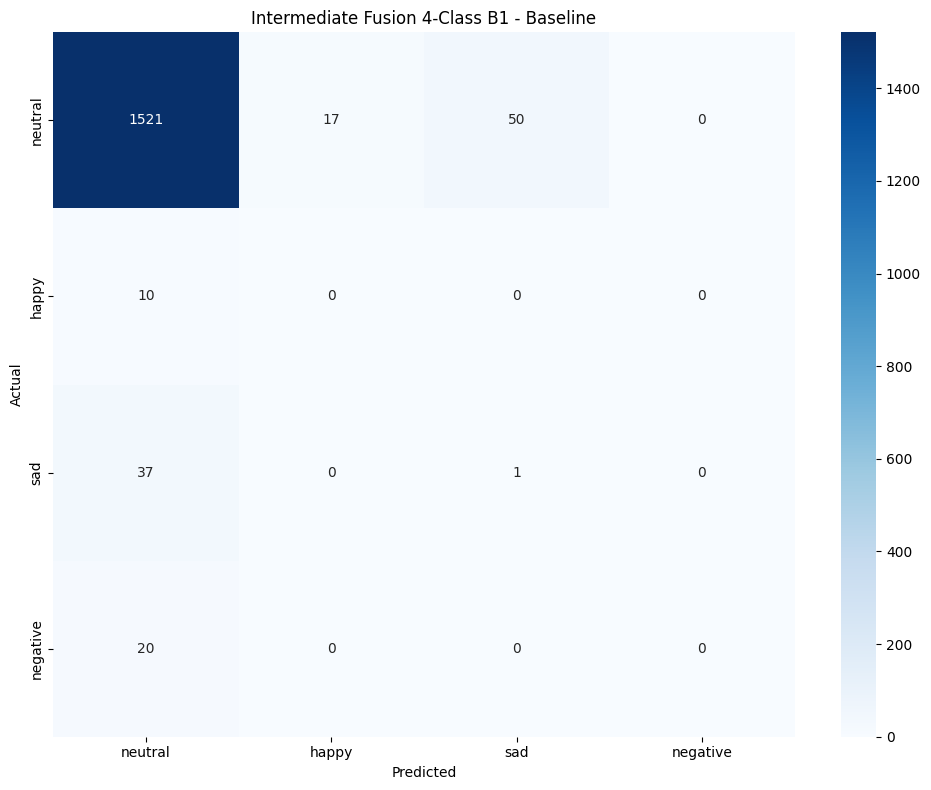

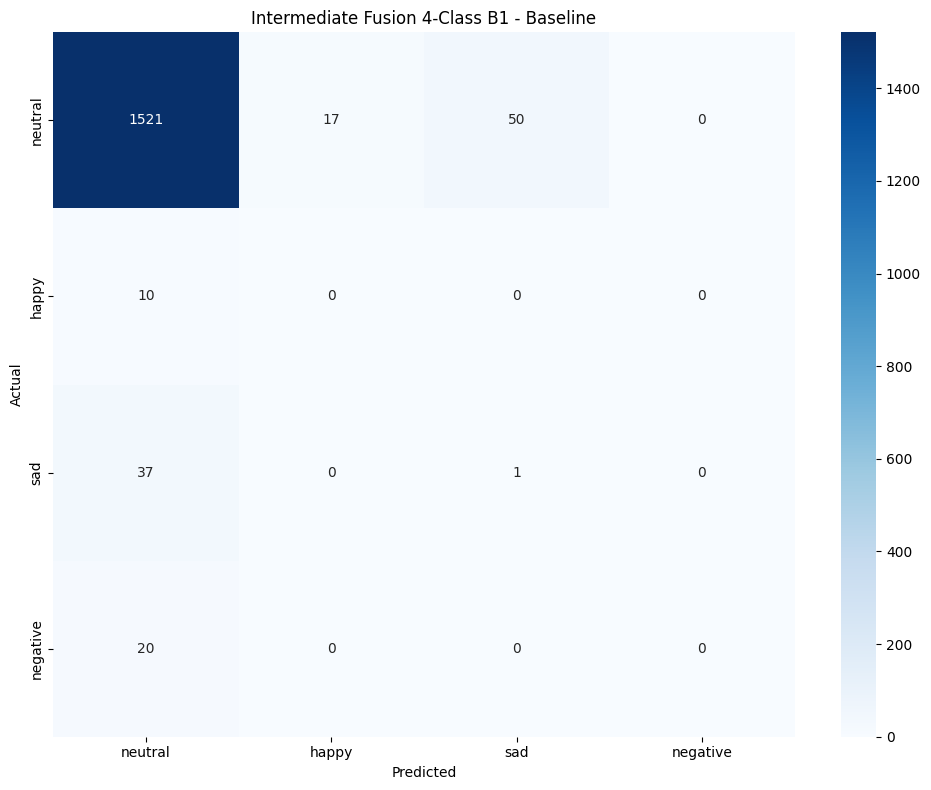

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fusion", emotions=EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "Intermediate Fusion 4-Class B1 - Baseline", emotions=EMOTIONS)

## 4. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = IntermediateFusion(num_classes=NUM_CLASSES, landmark_dim=136).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_4c_b2_weighted.pth")
)

Class weights: tensor([1.0000, 1.8865, 2.5717, 7.3799], device='cuda:0')



Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1934     0.6502     0.9724    0.9267   0.2405   0.000100  (46.2s)


     2      1.0536     0.7874     0.9887    0.7462   0.2179   0.000100  (46.3s)


     3      1.0004     0.7830     0.8704    0.7964   0.2947   0.000100  (46.2s)


...

    33      0.3003     0.8996     0.8016    0.8467   0.3343   0.000025  (46.3s)


    34      0.2825     0.9076     0.8656    0.8092   0.3225   0.000025  (46.2s)


    35      0.2826     0.9044     0.7938    0.8731   0.3518   0.000025  (46.3s)


    36      0.2748     0.9070     0.8186    0.8790   0.3586   0.000025  (46.2s)


    37      0.2758     0.9102     0.8358    0.8825   0.3616   0.000025  (46.3s)

Early stopping at epoch 37. Best epoch: 12 (val_f1=0.4589)

Best: epoch 12, val_acc=0.9353, val_f1=0.4589
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/intermediate_fusion/intermediate_4c_b2_weighted.pth


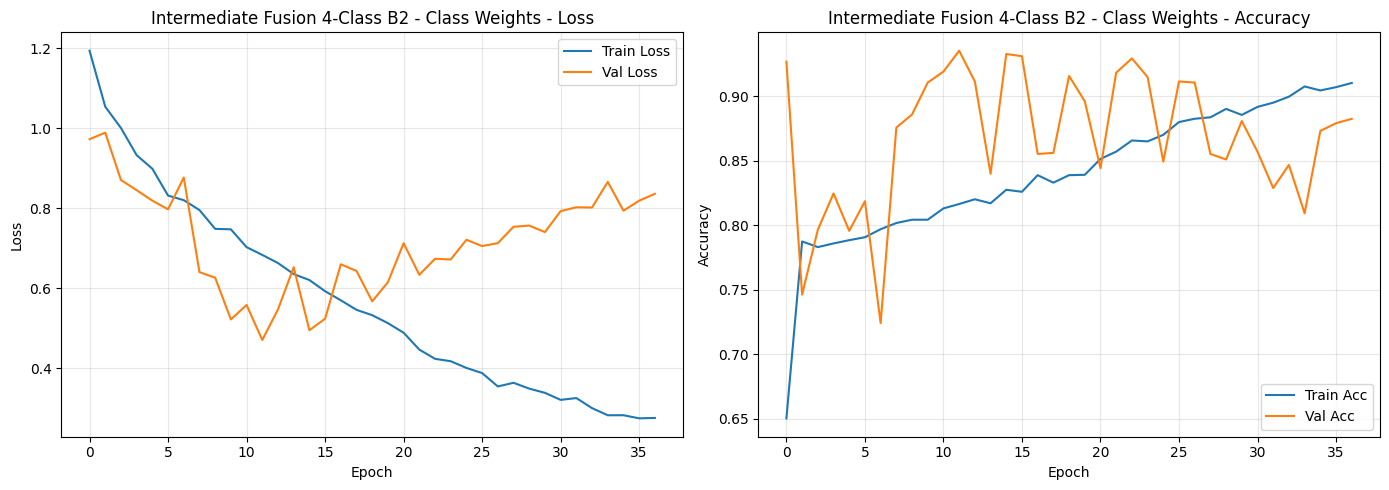

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.6462
Test Accuracy: 0.8726
Test Macro F1: 0.2581
Test Weighted F1: 0.8955

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.91      0.93      1588
       happy       0.03      0.30      0.05        10
         sad       0.05      0.05      0.05        38
    negative       0.00      0.00      0.00        20

    accuracy                           0.87      1656
   macro avg       0.26      0.31      0.26      1656
weighted avg       0.92      0.87      0.90      1656



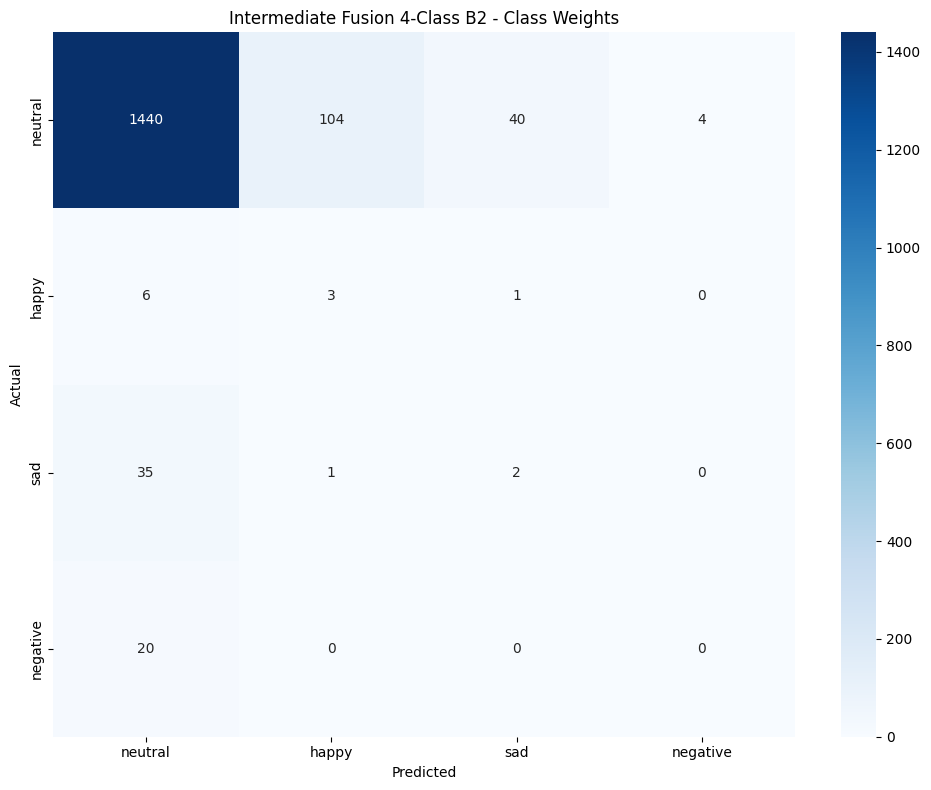

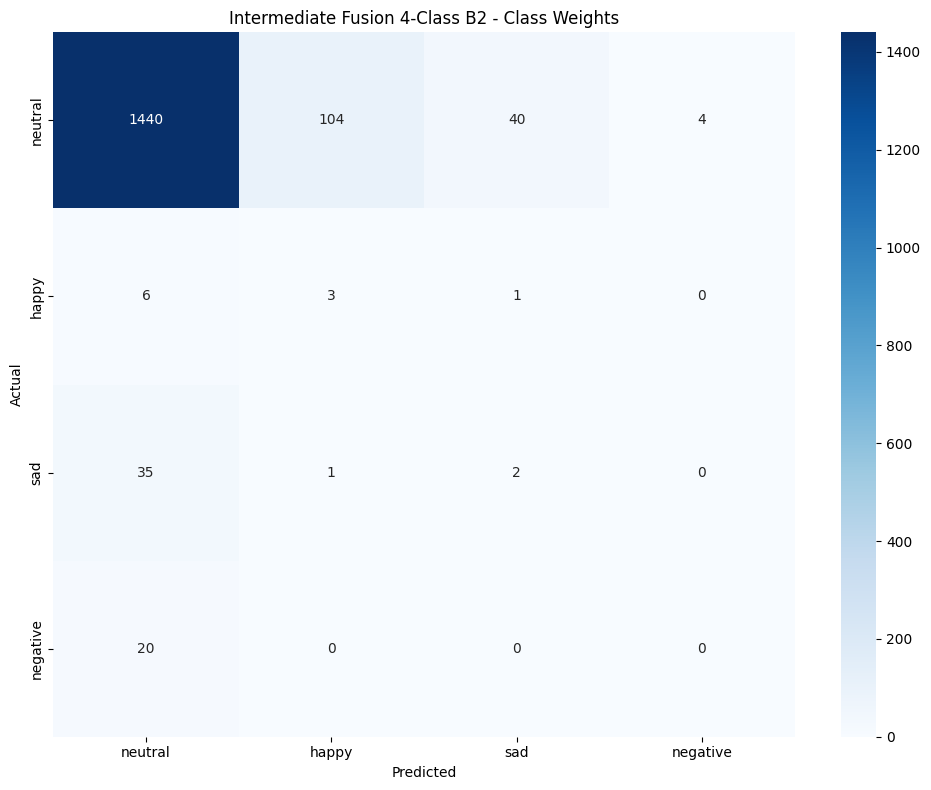

In [8]:
plot_training_history(history_b2, "Intermediate Fusion 4-Class B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fusion", emotions=EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "Intermediate Fusion 4-Class B2 - Class Weights", emotions=EMOTIONS)

## 5. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = IntermediateFusion(num_classes=NUM_CLASSES, landmark_dim=136).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_4c_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
    negative: 600
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 2.2080], device='cuda:0')



Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1228     0.6904     0.8623    0.9267   0.2405   0.000100  (50.3s)


     2      0.9716     0.7589     0.8368    0.9225   0.2399   0.000100  (50.3s)


     3      0.9161     0.7610     0.8430    0.8910   0.2572   0.000100  (50.2s)


...

    34      0.2035     0.9320     0.7141    0.8305   0.3389   0.000025  (50.4s)


    35      0.2052     0.9335     0.7110    0.8509   0.3475   0.000025  (50.3s)


    36      0.1974     0.9343     0.7661    0.8262   0.3283   0.000025  (50.3s)


    37      0.1841     0.9387     0.7569    0.8118   0.3328   0.000025  (50.2s)


    38      0.1907     0.9367     0.7682    0.7905   0.3193   0.000025  (50.2s)

Early stopping at epoch 38. Best epoch: 13 (val_f1=0.4402)

Best: epoch 13, val_acc=0.9233, val_f1=0.4402
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/intermediate_fusion/intermediate_4c_b3_augmented.pth


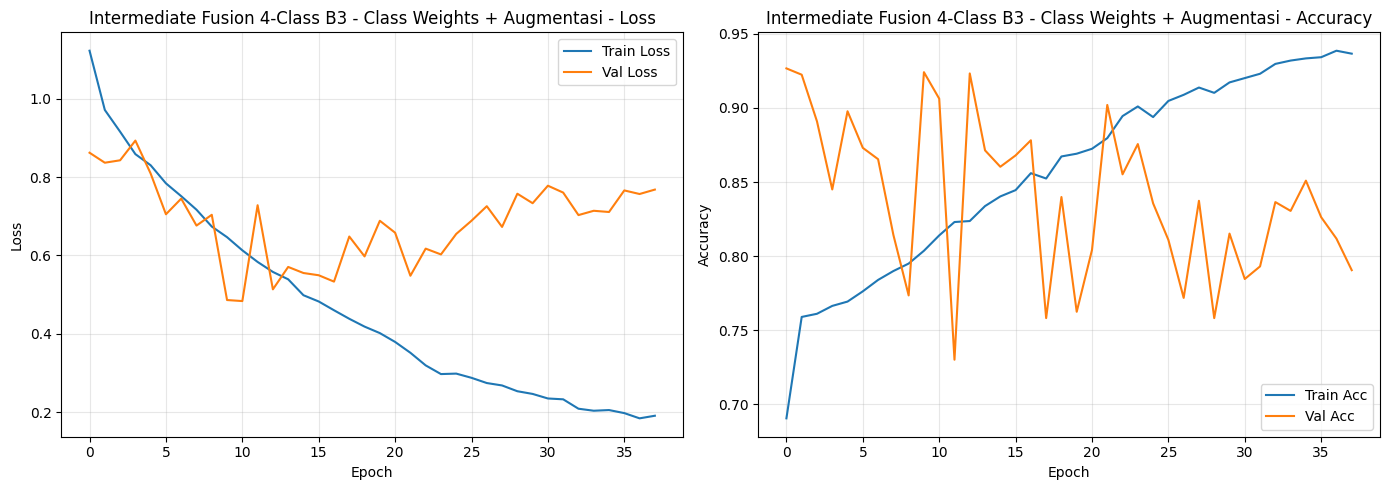

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.6647
Test Accuracy: 0.8297
Test Macro F1: 0.2380
Test Weighted F1: 0.8750

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.86      0.91      1588
       happy       0.00      0.00      0.00        10
         sad       0.03      0.11      0.04        38
    negative       0.00      0.00      0.00        20

    accuracy                           0.83      1656
   macro avg       0.25      0.24      0.24      1656
weighted avg       0.93      0.83      0.88      1656



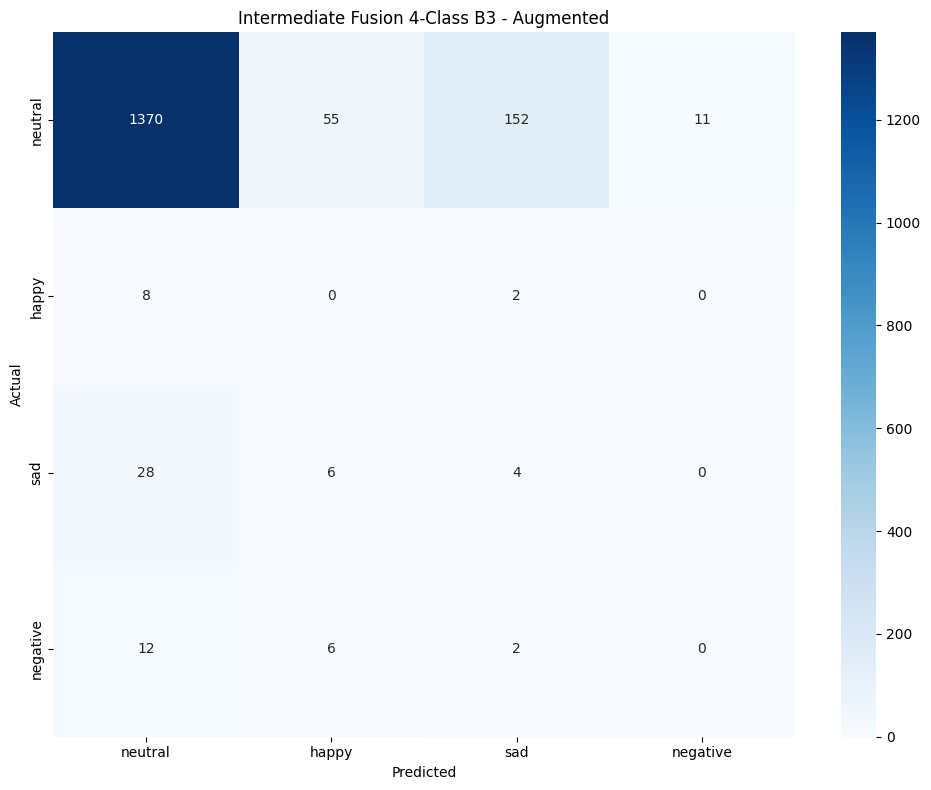

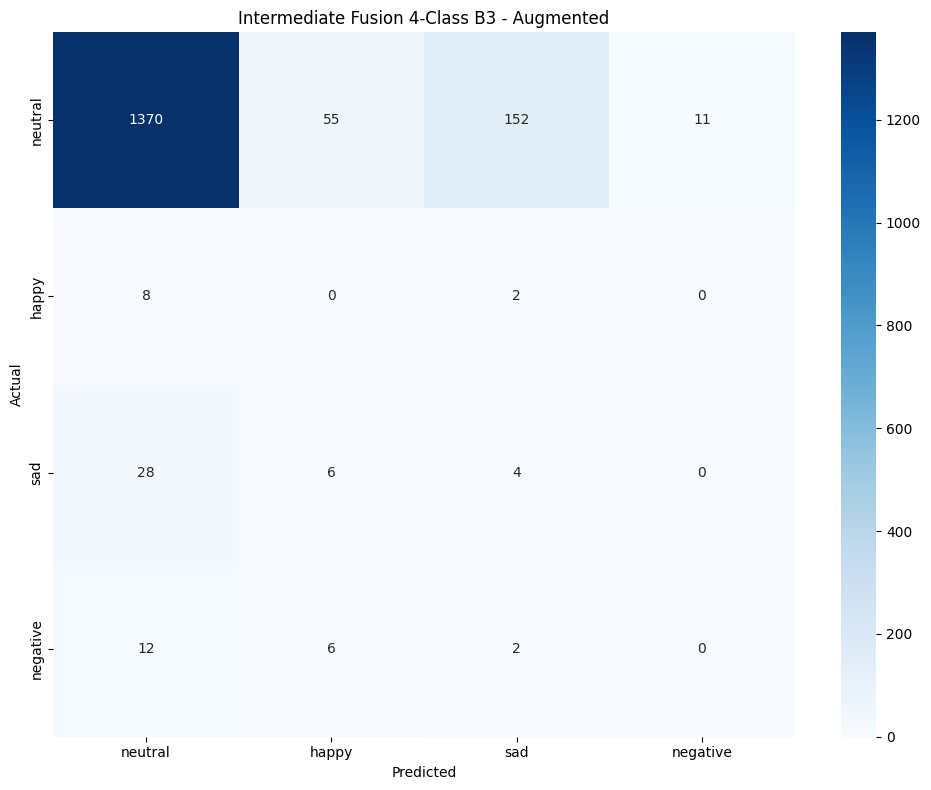

In [10]:
plot_training_history(history_b3, "Intermediate Fusion 4-Class B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fusion", emotions=EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "Intermediate Fusion 4-Class B3 - Augmented", emotions=EMOTIONS)

## 6. Perbandingan 3 Skenario

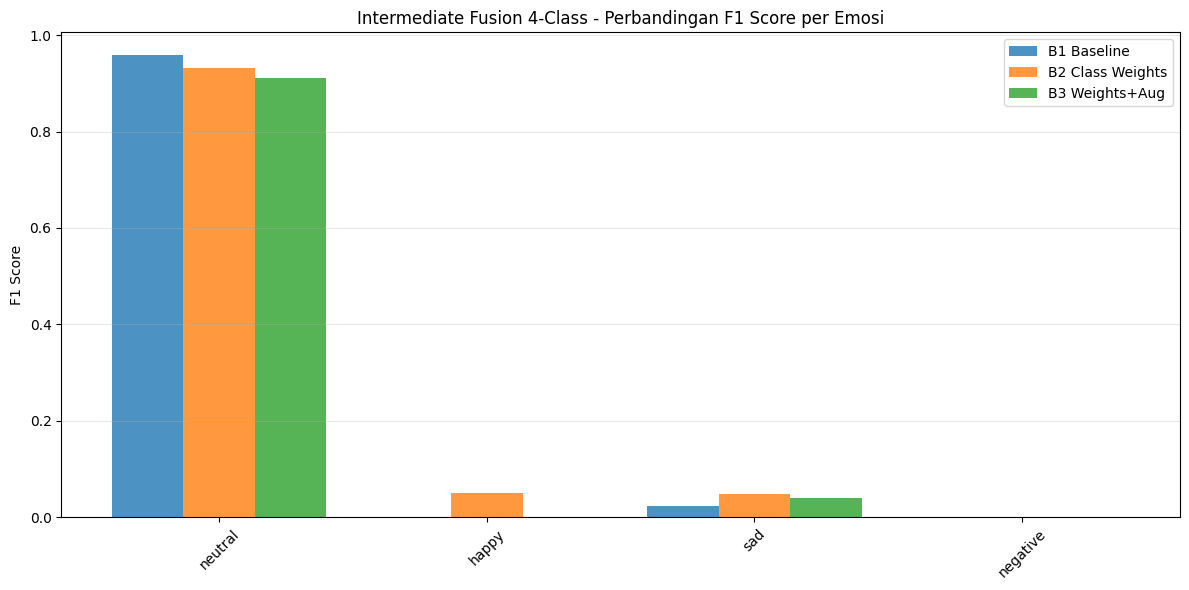

RINGKASAN INTERMEDIATE FUSION 4-CLASS - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9191     0.2451       0.9190
B2 Class Weights              0.8726     0.2581       0.8955
B3 Weights+Aug                0.8297     0.2380       0.8750


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "Intermediate Fusion 4-Class - Perbandingan F1 Score per Emosi", emotions=EMOTIONS)

# Summary table
print("=" * 70)
print("RINGKASAN INTERMEDIATE FUSION 4-CLASS - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

## 7. Simpan Hasil

In [12]:
# Save results
fusion_results = {}
for name, r in all_results.items():
    fusion_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "intermediate_fusion_4class_results.json", "w") as f:
    json.dump(fusion_results, f, indent=2)
print(f"Results saved to {OUTPUT_DIR / 'intermediate_fusion_4class_results.json'}")

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/4class/intermediate_fusion/intermediate_fusion_4class_results.json
